<a href="https://colab.research.google.com/github/ChronosXV/Aprendizaje-Automatico/blob/main/Grupo_Nro_02_Tema_ConsumoDigitalAdolescentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consumo Digital en Adolescentes**

## Integrantes del grupo:

* Gisela Martinez
* Noelia Cualina
* José Leonardo Carabajal
* Javier Carabajal

#Importacion de Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Ejecutamos el comando git clone y descargamos nuestro
!git clone https://{git_token}@github.com/ChronosXV/Aprendizaje-Automatico.git

Cloning into 'Aprendizaje-Automatico'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 49 (delta 9), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 16.33 MiB | 33.79 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [3]:
# Extraccion y tranformacion del conjunto de datos
path="/content/Aprendizaje-Automatico/tp1/repositorio.xlsx"
df = pd.read_excel(path)

# **Introducción**

##1. Dominio de Aplicación:
Se enmarca en la salud digital, los hábitos de vida y el bienestar en adolescentes de Argentina. Aborda el uso de dispositivos y pantallas (redes sociales, videojuegos, streaming) en relación con características demográficas, hábitos de sueño (duración, somnolencia diurna) y rendimiento escolar en jóvenes de entre 12 y 18 años.   



##2. Objetivos del Modelo:
El objetivo principal es identificar y caracterizar perfiles naturales de comportamiento mediante Aprendizaje Automático No Supervisado. Sus metas específicas son:   
* Segmentar: Agrupar a los adolescentes según sus patrones de uso de pantallas e información demográfica.  
* Validar: Probar la estabilidad de los grupos mediante distintas configuraciones experimentales.   
* Caracterizar: Comparar los segmentos con hábitos de descanso y desempeño académico.   



##3. Beneficios:
* Análisis detallado: Supera la visión simplificada de "horas totales de pantalla" al entender la composición y los dispositivos utilizados.
* Intervenciones precisas: Permite diseñar campañas de prevención, educación y concientización adaptadas a cada perfil.   
* Base para investigación: Genera evidencia útil para futuros estudios sobre salud digital y descanso juvenil.  

# **Analisis Exploratorio de Datos (EDA)**

In [4]:
# Estado inicial del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 4115
Columnas: 125


In [5]:
# Tipo de dato de cada columna
print(df.dtypes.value_counts())
print(df.columns[df.columns.duplicated()]) # nombres de columna repetidos

float64           66
int64             37
object            21
datetime64[ns]     1
Name: count, dtype: int64
Index([], dtype='object')


El archivo tiene 4.115 filas y 125 columnas, sin nombres de columna duplicados.

In [6]:
df.head()

,IP,Submission ID,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,181.45.234.85,4363218715845085057,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,0007-04-18 00:00:00,...,NaN,NaN,NaN,0,1,0,1,1,1,1
1,181.45.234.85,4363225955846355489,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,2007-01-24 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
2,181.45.234.85,4363219855845435174,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,2006-10-15 00:00:00,...,NaN,NaN,NaN,1,1,1,0,0,1,1
3,181.45.234.85,4363218145845601010,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,2006-10-05 00:00:00,...,NaN,NaN,NaN,1,1,0,1,1,1,1
4,181.45.234.85,4363224915847071805,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,0005-05-24 00:00:00,...,NaN,NaN,NaN,0,0,1,1,1,1,1


In [9]:
# Duplicados
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {cantidad_duplicados}")

key_columns = ['IP', 'Submission ID']
duplicates_in_keys = df[df.duplicated(subset=key_columns, keep=False)]
print(f"Duplicados en {key_columns}: {len(duplicates_in_keys)}")


Cantidad de filas duplicadas: 0
Duplicados en ['IP', 'Submission ID']: 0


In [10]:
# Muestra los nombres de las columnas como una lista de Python
print(df.columns.tolist())

['IP', 'Submission ID', 'Submission Date', 'Código', 'investigador', 'Colegio', 'Ciudad', 'grado', 'edad', 'Fecha de nacimiento', 'FECHA_NAC_RECOD', 'Sexo', 'sexonum', 'Altura en m', 'Peso en kg', 'imc', '¿Cuál es el máximo nivel educativo alcanzado por tu padre, madre o tutor?', 'niveducpadresRECOD', '¿Cuántos ambientes/habitaciones tiene el hogar donde vivís? (sin contar cocina y baño)', '¿Cuántos de estos ambientes/habitaciones se usan para dormir?', '¿Cuántas personas además de vos viven en el hogar?', 'cantpersonasviviendaRECOD', '¿Con qué frecuencia sentís tanto sueño que te cuesta prestar atención en la clase?', 'problemasatencionrecod', '¿Con qué frecuencia te quedás dormido/a o te da sueño mientras hacés la tarea?', '¿Estás atento/a o alerta en clase?', '¿Con qué frecuencia te sentís cansado y de mal humor durante el día?', '¿Te cuesta levantarte de la cama a la mañana?', '¿Te volvés a quedar dormido/a después de que te despertaron a la mañana?', '¿Necesitás que alguien te des

In [11]:
# Valores Faltantes por columna
faltantes = df.isna().mean().sort_values(ascending=False) * 100
print(faltantes.head(10).round(2))


WAZ                   99.34
prom                  69.45
aplazos               69.45
matematica            69.45
lengua                69.36
tpotvonlinePORC       27.85
tpotabletPORC         27.85
tporedesPORC          27.85
tpovideojuegosPORC    27.85
tpootrasPORC          27.85
dtype: float64


**Conclusión**: WAZ y las cuatro variables de rendimiento académico (prom, aplazos, matematica, lengua) tienen entre 69% y 99% de faltantes. Se descartan del modelado por inviables; las de notas se reservan para caracterizar los clusters solo si se decide trabajar con el subconjunto que sí las tiene (1.257 filas).

# **Definición de la población de trabajo**

El dataset trae banderas de completitud/exclusión con semánticas opuestas: en missingnotas, excluidos y excluFINAL, 1 = excluido/incompleto. En datoscompletoDEMOG, datoscompletoSUENO y datoscompletoPANTALLAS, 1 = completo. Filtrar por excluFINAL == 1 selecciona el grupo SIN notas y con datos completos de sueño/pantalla, que es lo opuesto a la muestra publicada por los autores (excluFINAL == 0, 864 filas).

In [ ]:
criterio = (df['excluidos'] == 0) & (df['edad'] <= 18)
base = df[df["excluidos"] == 0]
print('Población base (excluidos == 0):', len(base))
print('Casos con edad > 18:', (base['edad'] > 18).sum())
print(base.loc[base['edad'] > 18, 'edad'].value_counts().sort_index())

d = base[base["edad"] <= 18].copy()
print('N final (edad <= 18):', len(d))


Población base (excluidos == 0): 2449
Casos con edad > 18: 24
edad
19.0    20
20.0     4
Name: count, dtype: int64
N final (edad <= 18): 2425


**Conclusión**: La población de trabajo queda definida como excluidos == 0 y edad <= 18: 2.425 adolescentes. Se excluyen 24 casos (19-20 años) por estar fuera del rango etario del estudio original.

In [ ]:
# Chequeo de sesgo de seleccion
resto = df[~criterio]
print('Edad — incluido:', d['edad'].mean().round(2), '| excluido:', resto['edad'].mean().round(2))
print('Pantalla total — incluido:', d['tpopantallatotalhstrimmed'].mean().round(2), '| excluido:', resto['tpopantallatotalhstrimmed'].mean().round(2))
print('Sexo incluido:', d['Sexo'].value_counts(normalize=True).round(3).to_dict())
print('Sexo excluido:', resto['Sexo'].value_counts(normalize=True).round(3).to_dict())


Edad — incluido: 15.41 | excluido: 16.01
Pantalla total — incluido: 6.58 | excluido: 6.99
Sexo incluido: {'Femenino': 0.538, 'Masculino': 0.462}
Sexo excluido: {'Femenino': 0.576, 'Masculino': 0.424}


**Conclusión**: El grupo incluido es levemente más joven (15.41 vs. 16.01 años) y reporta algo menos de pantalla (6.58 vs. 6.99 h) que el excluido; ninguna diferencia es grande. En sexo, el grupo excluido tiene más proporción de mujeres (57.6% vs. 53.8%), una diferencia moderada, no un desbalance fuerte de 50/50 vs. 59/41 como se había reportado con el criterio anterior.

# **Variables de tiempo de pantalla**

In [ ]:
# Variables de tiempo de pantalla
print(d['tpopantallatotalhstrimmed'].describe().round(2))

cols_pantalla = ['tpovideojuegoshstrimmed', 'tpojuegotabletcelhstrimmed', 'tporedeshstrimmed',
                 'tpotvonlinehstrimeed', 'tpootrashstrimed']
print(d[cols_pantalla].describe().round(2).T[['count','mean','std','min','25%','50%','75%','max']])

print(d['tpopantallatotalhscat'].value_counts(dropna=False).sort_index())


count    1975.00
mean        6.58
std         2.92
min         0.00
25%         4.17
50%         6.33
75%         8.67
max        13.00
Name: tpopantallatotalhstrimmed, dtype: float64
                             count  mean   std  min   25%  50%   75%    max
tpovideojuegoshstrimmed     2425.0  0.95  1.73  0.0  0.00  0.0  1.17  12.00
tpojuegotabletcelhstrimmed  2425.0  1.73  2.15  0.0  0.17  1.0  2.33  12.50
tporedeshstrimmed           2425.0  2.93  2.52  0.0  1.00  2.0  4.00  12.83
tpotvonlinehstrimeed        2425.0  2.28  1.90  0.0  1.00  2.0  3.00  12.50
tpootrashstrimed            2415.0  0.79  1.59  0.0  0.00  0.0  1.00  12.00
tpopantallatotalhscat
0.0      3
1.0    684
2.0    824
3.0    464
NaN    450
Name: count, dtype: int64


**Conclusión**: El total de los autores (tpopantallatotalhstrimmed) queda nulo en 450 casos (18.6%) por el recorte de valores por encima de 13 h. Las 5 componentes por actividad están casi completas: solo tpootrashstrimed tiene 10 nulos.

In [ ]:
# Comprobacion ¿el total es la suma de los componentes?
d['suma_componentes'] = d[cols_pantalla].sum(axis=1, skipna=False)
diff = d['suma_componentes'] - d['tpopantallatotalhstrimmed']
print(diff.describe().round(2))

print('Total nulo:', d['tpopantallatotalhstrimmed'].isna().sum())
print('  de los cuales, con componentes completos:',
      ((d['tpopantallatotalhstrimmed'].isna()) & (d['suma_componentes'].notna())).sum())


count    1975.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64
Total nulo: 450
  de los cuales, con componentes completos: 440


**Conclusión**: El total coincide exactamente con la suma de los 5 componentes en los 1.975 casos donde ambos existen (diferencia = 0 siempre). De los 450 casos con total nulo, 440 tienen los 5 componentes disponibles: no son datos faltantes, son casos que superan el tope de 13 h que aplicaron los autores al total.

# **Reecontruccion: pantalla_total_final**

In [ ]:
# Reconstruccion: pantalla_total_final
LIMITE = 16
d['pantalla_total_final'] = d['tpopantallatotalhstrimmed']
usar_suma = d['pantalla_total_final'].isna() & (d['suma_componentes'] <= LIMITE)
d.loc[usar_suma, 'pantalla_total_final'] = d.loc[usar_suma, 'suma_componentes']

print('Faltantes finales:', d['pantalla_total_final'].isna().sum())
print('Casos rescatados desde la suma:', usar_suma.sum())
print(d['pantalla_total_final'].describe().round(2))
print('Casos del total ORIGINAL > 16h:', (d['tpopantallatotalhstrimmed'] > LIMITE).sum())


Faltantes finales: 256
Casos rescatados desde la suma: 194
count    2169.00
mean        7.27
std         3.56
min         0.00
25%         4.50
50%         6.67
75%         9.67
max        16.00
Name: pantalla_total_final, dtype: float64
Casos del total ORIGINAL > 16h: 0


**Conclusión**: Se define pantalla_total_final = total original, y donde es nulo se completa con la suma de componentes solo si esa suma es plausible (≤ 16 h, el mismo tope que nunca supera el total original). Esto recupera 194 de los 450 casos nulos y deja 256 faltantes reales (10.6% de la población), frente al 18.6% del total original. Es la variable central para el análisis de intensidad de uso; para el análisis de composición se siguen usando las 5 componentes por separado.

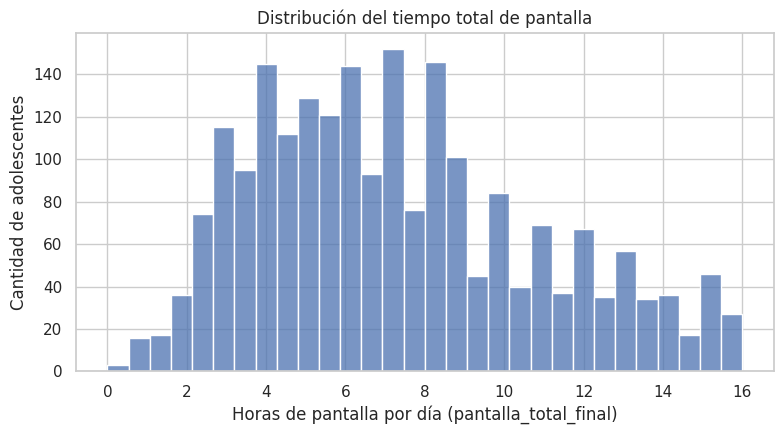

In [ ]:

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(d['pantalla_total_final'].dropna(), bins=30, color='#4C72B0', ax=ax)
ax.set_xlabel('Horas de pantalla por día (pantalla_total_final)')
ax.set_ylabel('Cantidad de adolescentes')
ax.set_title('Distribución del tiempo total de pantalla')
plt.tight_layout()
plt.show()

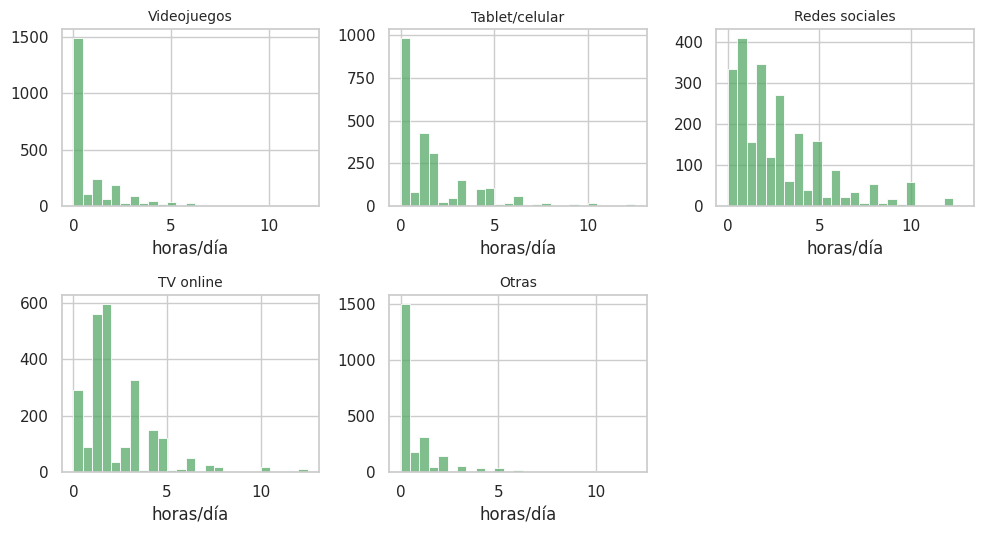

In [ ]:
NOMBRES = {
    'tpovideojuegoshstrimmed': 'Videojuegos',
    'tpojuegotabletcelhstrimmed': 'Tablet/celular',
    'tporedeshstrimmed': 'Redes sociales',
    'tpotvonlinehstrimeed': 'TV online',
    'tpootrashstrimed': 'Otras',
}

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
for ax, c in zip(axes.ravel(), cols_pantalla):
    sns.histplot(d[c].dropna(), bins=25, color='#55A868', ax=ax)
    ax.set_title(NOMBRES[c], fontsize=10)
    ax.set_xlabel('horas/día')
    ax.set_ylabel('')

axes.ravel()[-1].axis('off')  # el sexto panel queda vacío (son 5 componentes)
plt.tight_layout()
plt.show()

Todas las actividades concentran la mayoría de los casos en cero horas, sobre todo videojuegos y 'otras'. Esto indica que conviene tratarlas como variables con exceso de ceros al momento de escalar para el clustering

**Sueño y somnolencia**

In [ ]:
# Sueño y somnolencia
print(d['tposueñosem'].describe().round(2))
print('Faltantes:', d['tposueñosem'].isna().sum())

print(d['tpofsueñosem'].describe().round(2))
print('Faltantes:', d['tpofsueñosem'].isna().sum())

print(d['Resultado'].describe().round(2))
print(d['somno01pdss'].value_counts(dropna=False))


count    2425.00
mean        7.11
std         1.22
min         4.00
25%         6.47
50%         7.17
75%         7.83
max        11.83
Name: tposueñosem, dtype: float64
Faltantes: 0
count    2425.00
mean        9.40
std         1.98
min         1.00
25%         8.17
50%         9.50
75%        10.67
max        14.00
Name: tpofsueñosem, dtype: float64
Faltantes: 0
count    2425.00
mean       18.25
std         5.11
min         2.00
25%        15.00
50%        18.00
75%        22.00
max        31.00
Name: Resultado, dtype: float64
somno01pdss
1    1698
0     727
Name: count, dtype: int64


**Conclusión**: Las variables de sueño no tienen faltantes en esta población (el indicador datoscompletoSUENO cumple lo que promete). La duración media es 7.11 h entre semana y 9.40 h en fin de semana; ambas por debajo de las 8-10 h recomendadas para esta franja etaria. El 70.0% de los casos (1.698 de 2.425) tiene somnolencia diurna positiva (somno01pdss = 1).

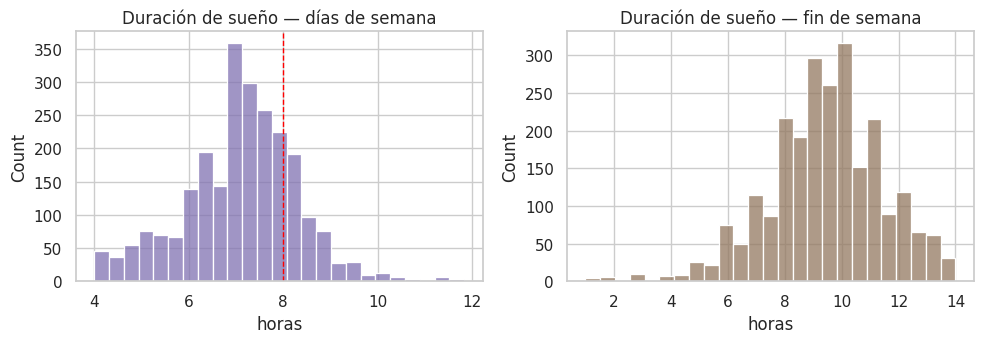

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

sns.histplot(d['tposueñosem'].dropna(), bins=25, color='#8172B2', ax=axes[0])
axes[0].set_title('Duración de sueño — días de semana')
axes[0].set_xlabel('horas')
axes[0].axvline(8, color='red', ls='--', lw=1)

sns.histplot(d['tpofsueñosem'].dropna(), bins=25, color='#937860', ax=axes[1])
axes[1].set_title('Duración de sueño — fin de semana')
axes[1].set_xlabel('horas')

plt.tight_layout()
plt.show()

Entre semana, la mayoría duerme por debajo de las 8 h recomendadas (línea roja); el fin de semana la distribución se corre hacia la derecha, con una diferencia de más de 2 h en la media.

In [ ]:
# difonsetsueño: valores extremos
print(d["difonsetsueño"].describe(percentiles=[.9,.95,.99]).round(2))
print('Casos > 8h:', (d['difonsetsueño'] > 8).sum())


count    2425.00
mean        3.21
std         3.71
min         0.00
50%         2.00
90%         7.00
95%        13.50
99%        15.50
max        17.17
Name: difonsetsueño, dtype: float64
Casos > 8h: 227


**Conclusión**: difonsetsueño (diferencia de horario de inicio de sueño entre semana y fin de semana) llega a 17.17 h, un valor no creíble para esta medida. Hay 227 casos (9.4%) por encima de 8 h, y el salto entre el percentil 90 (7.0) y el 95 (13.5) sugiere un problema de cálculo, no una cola natural de la distribución.

In [ ]:
# Recálculo directo desde las horas de acostarse
d['diff_recalculada'] = (d['horaacostarfsemanahr'] - d['horasueñosemanahr']).abs()
print(d["diff_recalculada"].describe(percentiles=[.9,.95,.99]).round(2))

comparacion = (d['diff_recalculada'] - d['difonsetsueño']).abs()
print('Coinciden (dif < 0.1h):', (comparacion < 0.1).sum())
print('No coinciden:', (comparacion >= 0.1).sum())


count    2425.00
mean        2.15
std         1.62
min         0.00
50%         1.83
90%         4.50
95%         5.50
99%         7.00
max         9.50
Name: diff_recalculada, dtype: float64
Coinciden (dif < 0.1h): 2203
No coinciden: 222


**Conclusión**: El cálculo directo (diff_recalculada) tiene un máximo creíble de 9.5 h y coincide con la columna original en 2.203 de 2.425 casos (90.8%). Se descarta difonsetsueño tal como viene en el dataset y se usa diff_recalculada, por la inconsistencia detectada en el 9.2% restante (222 casos).

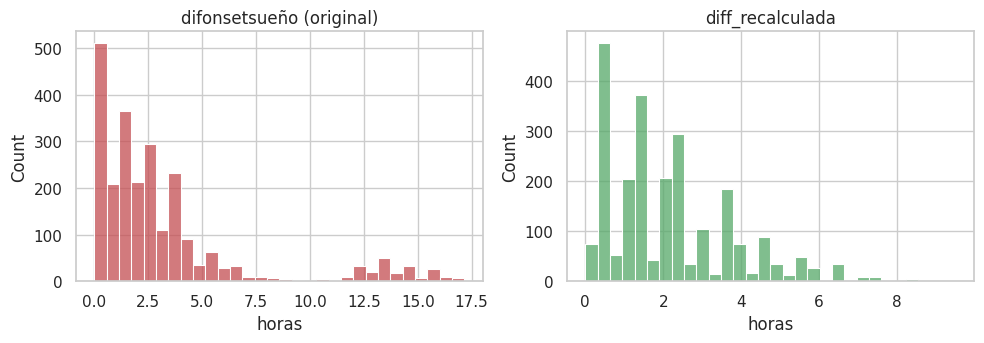

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

sns.histplot(d['difonsetsueño'].dropna(), bins=30, color='#C44E52', ax=axes[0])
axes[0].set_title('difonsetsueño (original)')
axes[0].set_xlabel('horas')

sns.histplot(d['diff_recalculada'].dropna(), bins=30, color='#55A868', ax=axes[1])
axes[1].set_title('diff_recalculada')
axes[1].set_xlabel('horas')

plt.tight_layout()
plt.show()

La variable original tiene una cola hasta 17 h, no creíble como diferencia de horario de sueño. La recalculada tiene un máximo de 9.5 h, coherente con lo esperado, por lo que se descarta la original y se usa esta en el resto del análisis.

# **Relacion entre pantalla y sueño/Somnolencia**

In [ ]:
# Relación entre pantallas y sueño/somnolencia
cols_numericas = ['pantalla_total_final'] + cols_pantalla + ['tposueñosem', 'tpofsueñosem', 'Resultado']
print(d[cols_numericas].corr(method='spearman').round(2)['pantalla_total_final'])

print(d.groupby('somno01pdss')['tposueñosem'].describe()[['count','mean','std']].round(2))


pantalla_total_final          1.00
tpovideojuegoshstrimmed       0.25
tpojuegotabletcelhstrimmed    0.44
tporedeshstrimmed             0.54
tpotvonlinehstrimeed          0.50
tpootrashstrimed              0.26
tposueñosem                  -0.13
tpofsueñosem                 -0.04
Resultado                     0.09
Name: pantalla_total_final, dtype: float64
              count  mean   std
somno01pdss                    
0             727.0  7.32  1.21
1            1698.0  7.02  1.20


**Conclusión**: El tiempo total de pantalla correlaciona débilmente con sueño en semana (-0.13), sueño en fin de semana (-0.04) y somnolencia (0.09). La diferencia de sueño entre adolescentes con y sin somnolencia positiva es de apenas 18 minutos (7.02 h vs. 7.32 h). Esta ausencia de relación lineal fuerte con el tiempo TOTAL respalda buscar perfiles según la composición de uso (en qué se usa la pantalla, no solo cuánto) mediante clustering, en lugar de predecir sueño desde un único indicador agregado. La correlación de Spearman solo capta relaciones monótonas; no descarta patrones no lineales que el clustering sí podría revelar.

# **Posibles Variables descartadas**

**Variable**: WAZ,	% faltantes 99.34 %.
**Motivo**: Prácticamente vacía.    

**Variable**: prom, aplazos, matematica, lengua, % faltante	~69.4%.
**Motivo**:	Solo disponibles para el subconjunto con notas (1.257 filas).        

**Variable**: tpopantallatotalhstrimmed (usada sola), % faltante	18.6% en esta población.
**Motivo**: Reemplazada por pantalla_total_final.

**Variable**: difonsetsueño (original),	% faltante: 0%, pero con valores no creíbles.	**Motivo**:Reemplazada por diff_recalculada



# **Conclusion General EDA**

**Fuente y estructura**
El archivo repositorio.xlsx contiene 4.115 registros y 125 columnas, sin filas ni columnas duplicadas. Es una versión ampliada del dataset publicado (1.257 adolescentes).

**Población de trabajo**
Se definió como excluidos == 0 y edad <= 18, dejando 2.425 adolescentes. El criterio de los autores (excluFINAL) tiene la semántica invertida respecto de lo que se buscaba: excluFINAL == 1 selecciona los casos SIN notas, no los que las tienen. El grupo excluido no difiere fuertemente del incluido en edad, pantalla o sexo.

**Variables de pantalla**
Se trabaja con pantalla_total_final (suma de componentes cuando el total original es nulo y es ≤ 16 h; 256 faltantes, 10.6%) para intensidad, y con las 5 componentes por separado para composición de uso.

**Sueño**
Sin faltantes en las variables principales. Se descarta difonsetsueño original por inconsistencias en 9.2% de los casos, reemplazada por diff_recalculada.

**Relación pantalla-sueño**
Correlaciones débiles entre el tiempo total de pantalla y sueño/somnolencia, lo que respalda buscar perfiles por composición de uso mediante clustering en lugar de un modelo agregado.

**Variables descartadas**
WAZ y las variables de rendimiento académico, por su alto nivel de faltantes.


**Dataset Resultante para el modelado**

**Elemento**: Población	 **Valor**: excluidos == 0 y edad <= 18 → 2.425 filas

**Elemento**: Intensidad de pantalla **Valor**: pantalla_total_final (2.169 casos no nulos)

**Elemento**: Composición de pantalla **Valor**: 5 componentes trimmed (2.415 casos completos)

**Elemento**: Variables de sueño	  **Valor**: tposueñosem, tpofsueñosem, diff_recalculada, Resultado (sin faltantes)

**Elemento**: Caracterización posterior **Valor**: Sexo, grado, sueño, somnolencia, Colegio (no entran al clustering)

**Elemento**: Descartadas **Valor**: WAZ, prom, aplazos, matematica, lengua, difonsetsueño original
